# Green Village: Starting test
This code covers the exploration and analysis of the data on photovoltaic panels installed at the Green Village, TU Delft. This includes components like the solar panels, MPPT & Inverter.


#### Data import

This section covers the data import. Names and variables are also set up here, as well as package import.

In [1]:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""


#Setting up the environment:
import matplotlib.pyplot as plt
import random
import pandas as pd
import numpy as np
import chardet
#import matplotlib.image as mpimg # Used later to export to PNG)

#The following data is given to be directly from the database by Marijn (GV)
data = "SSS-August-small-resampled-v3.csv"

# Detect data type (gave me problems before, so we just check to be sure)
with open(data, 'rb') as f:
    result = chardet.detect(f.read(10000))
print(result)
encoding = result['encoding']
print(f"Detected encoding: {encoding}")

#First the data is imported:
data = pd.read_csv(data, encoding='UTF-16') # UTF-16 was needed: otherwise the data had problems, as shown above
print(f"the data exists of the columns:\n", data.columns)

{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}
Detected encoding: UTF-16
the data exists of the columns:
 Index(['time', 'value_float', 'device_id', 'measurement_id', 'application_id',
       'name'],
      dtype='object')


In [3]:
# Then the data is trimmed down to the timestamps we are interested in:
# Quick note: all data is shifted by 2 hours from the real time data in Grafana

data['time'] = pd.to_datetime(data['time'],format='ISO8601') # The time format gave me problems, so it is specified here.

# The following time stamps are testing times
start_date = '2024-08-05 00:00:00'
end_date = '2024-08-6 23:59:59'
start_date = pd.to_datetime(start_date).tz_localize('UTC')
end_date = pd.to_datetime(end_date).tz_localize('UTC')


# The following time stamps are the week of interest, not used in testing:
#start_date = '2024-08-05 00:00:00'
#end_date = '2024-08-11 23:59:59'

# We trimm the data to work with down
data = data[(data['time'] >= start_date) & (data['time'] <= end_date)] 



In [5]:
# Some variables & constants:
LHV_H2 = 120000000 # J/kg
HHV_H2 = 142000000 # J/kg
MolarVolume = 22.414 # L/mol.
MolarMass = 2.016 # g/mol
H2Density = MolarMass/MolarVolume # g/L

#### General functions
Some functions are generated for later ease-of-use. The first function is a plotting function that can take the created variables and automatically plot them as desired:

In [7]:
# Setting up plotting layout
figdim=(6.4, 4.8)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()


In [9]:
# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_h2(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
    else:
        print(f"Variable '{var}' not found!")  
    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.title('Hydrogen production over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return H2Prod


#### Date Pre-Processing
Here the data is preproccessed as the data is not yet formatted to convienently work with the data

In [11]:
# Make subsets of data to work with
grouped = data.groupby(['device_id', 'measurement_id'])

device_measurement_dict = {}

for (device, measurement), group in grouped:
    var_name = f"{device}_{measurement}".replace(" ", "_")
    globals()[var_name] = group
    device_measurement_dict[(device, measurement)] = group

# Now, display the names of all the new variables, so we can use them later
new_var_names = [f"{device}_{measurement}".replace(" ", "_") for device, measurement in device_measurement_dict.keys()]
print("Newly created variables:")
for var in new_var_names:
    print(var)


Newly created variables:
Battery_Current
Battery_Power
Battery_State_Of_Charge
Battery_Temperature
Battery_Voltage
Battery_Inverter_AC_In_Power
Battery_Inverter_AC_Out_Power
Battery_Inverter_Grid_Setpoint
Compressor_Anode_Dewpoint
Compressor_Anode_Heat_Tracing_Control_Signal
Compressor_Anode_Heat_Tracing_Temperature
Compressor_Anode_Pressure
Compressor_Anode_Relative_Humidity
Compressor_Anode_Temperature
Compressor_Cathode_Pressure
Compressor_Compressor_Coolant_Flow
Compressor_Compressor_Coolant_Temperature_In
Compressor_Compressor_Coolant_Temperature_Out
Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal
Compressor_Compressor_Cooling_Pump_Control_Signal
Compressor_Current_State
Compressor_Dryer_Pressure
Compressor_Hydraulic_Pressure
Compressor_Internal_Cooling_Heater_Control_Signal
Compressor_PLC_Alarm_Register
Compressor_PLC_Warning_Register
Compressor_PLC_Yield_Output
Compressor_PSU_Alarm_Register
Compressor_PSU_Control_Register
Compressor_PSU_Current_Energy_Consumption
C

##### Resampling
Here zeros are added to the data if necessary. This can be checked by looking at the hydrogen flow signal.

In [61]:
# Note that the following function is provided by ChatGPT:
# Also note this function does not work perfectly yet if the time window is changed... 

modified_dfs = {}

def zerogaps(df):
    # Ensure 'time' column is in datetime format
    df['time'] = pd.to_datetime(df['time']) 
    
    # Sort by time
    df = df.sort_values('time')

    # Calculate the time difference between consecutive rows
    df['time_diff'] = df['time'].diff().dt.total_seconds()

    # Create a list to hold new rows
    new_rows = []

    # Iterate over rows to check for time gaps and insert zero rows
    for i in range(1, len(df)):
        if df['time_diff'].iloc[i] > 61: # length in seconds of no data (note sampling is done at 60s)
            # Find the gap start and end
            gap_start = df['time'].iloc[i-1]
            gap_end = df['time'].iloc[i]
            
            # Generate time intervals within the gap
            gap_times = pd.date_range(gap_start, gap_end, freq='1min')
            
            # Create rows for the gap with zero values
            for time in gap_times:
                new_row = {
                    'time': time,
                    #'name': df['name'].iloc[i-1],  # Fill with the previous row's value or adjust accordingly
                    #'application_id': df['application_id'].iloc[i-1],
                    'device_id': df['device_id'].iloc[i-1],
                    'measurement_id': df['measurement_id'].iloc[i-1],
                    'value_float': 0
                }
                new_rows.append(new_row)

    # Handle missing data before the first timestamp (if any)
    if df['time'].iloc[0] > start_date:
        before_start = pd.date_range(start_date, df['time'].iloc[0], freq='1s')
        for time in before_start:
            new_row = {
                'time': time,
                #'name': df['name'].iloc[0],  # Adjust to first row's value or placeholder
                #'application_id': df['application_id'].iloc[0],
                'device_id': df['device_id'].iloc[0],
                'measurement_id': df['measurement_id'].iloc[0],
                'value_float': 0
            }
            new_rows.append(new_row)

    # Handle missing data after the last timestamp (if any)
    if df['time'].iloc[-1] < end_date:
        after_end = pd.date_range(df['time'].iloc[-1], end_date, freq='1s')
        for time in after_end:
            new_row = {
                'time': time,
                #'name': df['name'].iloc[-1],  # Adjust to last row's value or placeholder
                #'application_id': df['application_id'].iloc[-1],
                'device_id': df['device_id'].iloc[-1],
                'measurement_id': df['measurement_id'].iloc[-1],
                'value_float': 0
            }
            new_rows.append(new_row)

    # Convert new rows into a DataFrame and append them to the original data
    new_df = pd.DataFrame(new_rows)
    df = pd.concat([df, new_df]).sort_values('time').reset_index(drop=True)

    # Optionally drop the 'time_diff' column
    df = df.drop(columns=['time_diff'])
    
    return df

# We can now use ChatGPT's function to fill in all missing datapoints:
for var in new_var_names:
    globals()[var] = zerogaps(globals()[var])



New version of the zerogaps functions:

In [28]:
def zerogapsv2(df):
    # Ensure the 'time' column exists
    # Convert 'time' column to datetime
# Ensure 'time' column is in datetime format
    df['time'] = pd.to_datetime(df['time']) 
    
    # Sort by time
    df = df.sort_values('time')
    df.set_index('time', inplace=True)

    # Generate a complete range of timestamps with 1-minute frequency
    full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')

    # Reindex the DataFrame to the full time range
    df = df.reindex(full_time_range)

    # Fill missing values with zeros for all columns (except index)
    df.fillna(0, inplace=True)

    # Reset the index to make 'time' a column again
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'time'}, inplace=True)

    return df

# We can now use ChatGPT's function to fill in all missing datapoints:
for var in new_var_names:
    df = globals()[var]
    globals()[var] = zerogapsv2(df)

In [15]:
Temperature_Control_Fuel_Cell_Buffer_Cooling_Control_Signal.columns

Index(['time', 'value_float', 'device_id', 'measurement_id', 'application_id',
       'name'],
      dtype='object')

#### Data Visualisation
Here, each variable is plotted against time to gain an idea of what the data looks like on the first run:

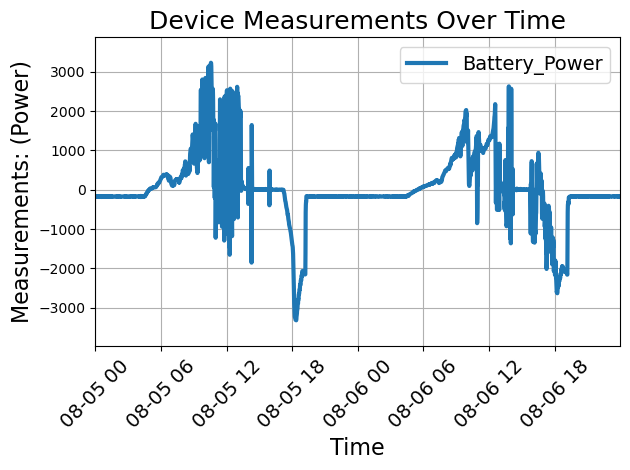

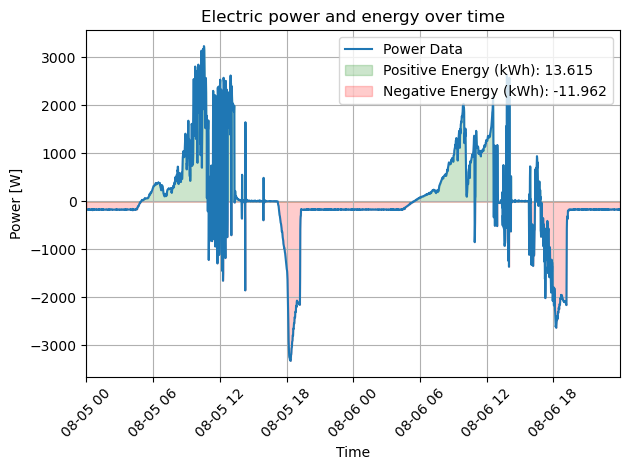

Energy Supplied to the battery by the solar panels (Positive): 13.615 kWh
Energy Consumed (Negative): -11.962 kWh
Total net energy exchange: 1.653 kWh


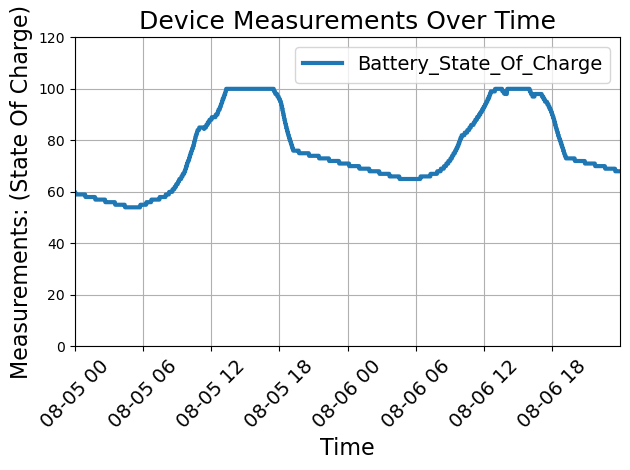

In [17]:
# Example: Battery current, first the table is shown en then the data plot using my auto-plot function
fplot('Battery_Power')

Battery_Energy = integrate_hr('Battery_Power')
print(f"Energy Supplied to the battery by the solar panels (Positive): {Battery_Energy[1]:.3f} kWh")
print(f"Energy Consumed (Negative): {Battery_Energy[2]:.3f} kWh")
print(f"Total net energy exchange: {Battery_Energy[0]:.3f} kWh")
fplot('Battery_State_Of_Charge')



#### Issue ticketing
Fixing issues and testing new scripts

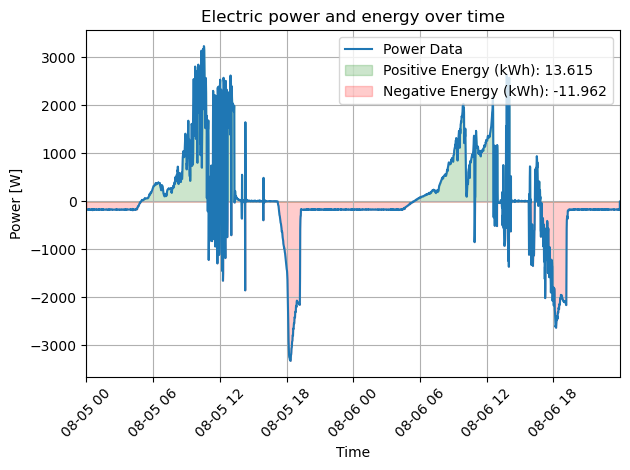

,time,value_float,device_id,measurement_id,application_id,name
0,2024-08-05 00:00:00+00:00,-3.340000,Battery,Current,Battery System,Seasonal_Storage_System
1,2024-08-05 00:01:00+00:00,-3.311667,Battery,Current,Battery System,Seasonal_Storage_System
2,2024-08-05 00:02:00+00:00,-3.261667,Battery,Current,Battery System,Seasonal_Storage_System
3,2024-08-05 00:03:00+00:00,-3.281667,Battery,Current,Battery System,Seasonal_Storage_System
4,2024-08-05 00:04:00+00:00,-3.300000,Battery,Current,Battery System,Seasonal_Storage_System


In [109]:
# Testing the integration script:
integrate_hr('Battery_Power')
# Perform integration
Battery_Current.head()



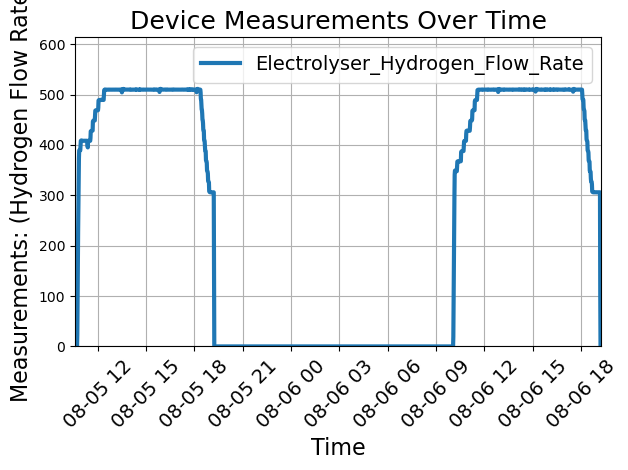

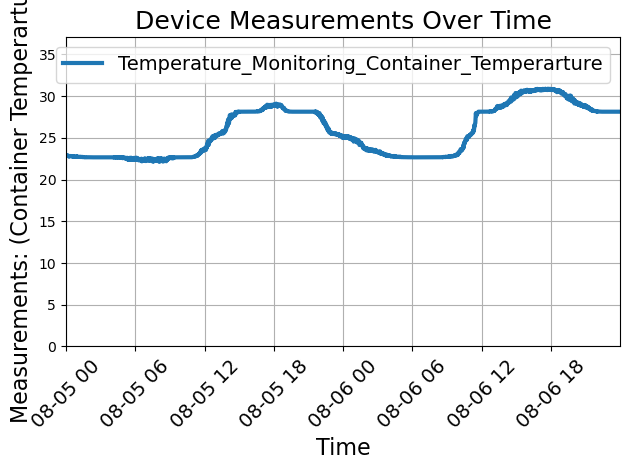

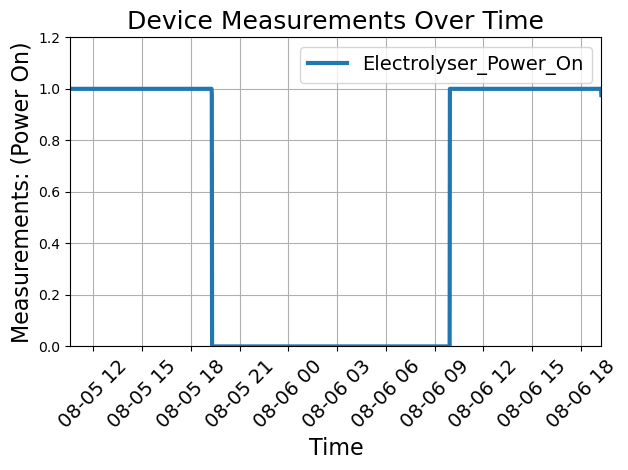

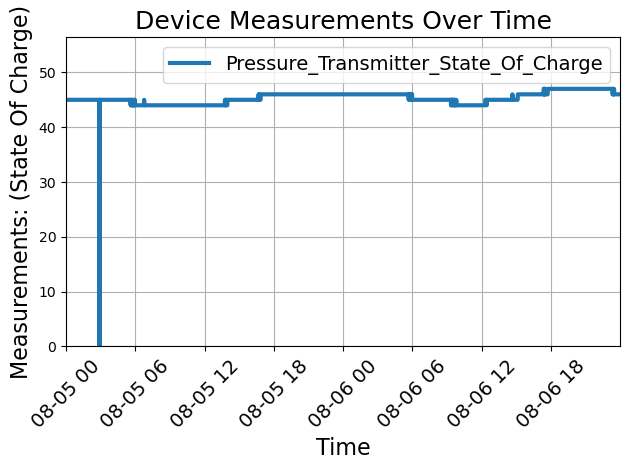

In [19]:
# Testing for the missing data points:
# The current code trims down on X to only show the available points in the timespan
fplot('Electrolyser_Hydrogen_Flow_Rate')
#Electrolyser_Hydrogen_Flow_Rate.head()

fplot('Temperature_Monitoring_Container_Temperarture')

fplot('Electrolyser_Power_On')

fplot('Pressure_Transmitter_State_Of_Charge')

Testing the integration accuracy: (Use % as Watts) for simple manual calculation

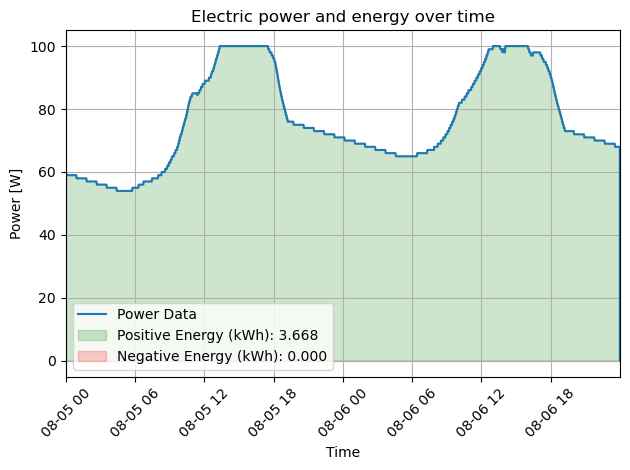

Energy Supplied to the battery by the solar panels (Positive): 3.668 kWh
Energy Supplied to the battery by the solar panels (Positive): 1.797 kWh


In [77]:
testenergy = integrate_hr('Battery_State_Of_Charge')
print(f"Energy Supplied to the battery by the solar panels (Positive): {testenergy[1]:.3f} kWh")

meanSOC = Battery_State_Of_Charge['value_float'].mean()

testenergy2 = meanSOC*24/1000

print(f"Energy Supplied to the battery by the solar panels (Positive): {testenergy2:.3f} kWh")
# We conclude the function is working correctly 

#### Solar energy generation

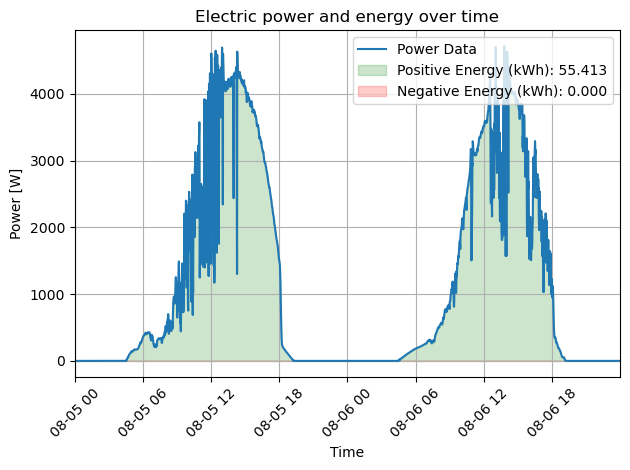

In [79]:
Solarenergy_Production = integrate_hr('PV_Inverter_Active_Power')


#### Hydrogen production

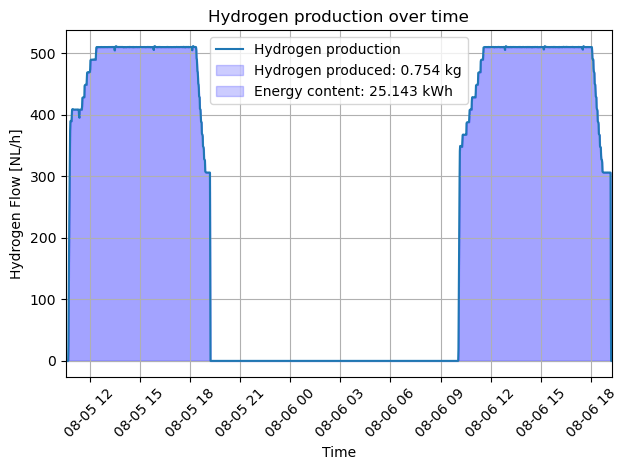

In [21]:
Hydrogen_Production = integrate_h2('Electrolyser_Hydrogen_Flow_Rate')
